# Test

In [ ]:
import imageio

import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt

# Базовая модель

In [ ]:
class MoralEntrepreneurModel:
    def __init__(
        self, n_agents:int=100, n_agents_mode:int=4, max_periods:int=100, network_type:str='watts', beliefs_mean:float=0, beliefs_std:float=1,
        conformity_min:float=0, conformity_max:float=1,
        strategy_type_me:str='common', propaganda_me:float=0, target_rate_me:float=0.1,
        strategy_type_fd:str='common', propaganda_fd:float=0, target_rate_fd:float=0.1):

        self.n_agents = n_agents # количество агентов
        self.max_periods = max_periods # максимальное число тактов

        self.beliefs_mean = beliefs_mean # мат. ожидание для моральности индивидов
        self.beliefs_std = beliefs_std # стд. отклонение для моральности индивидов
        self.conformity_min = conformity_min # минимум для конформности индивидов
        self.conformity_max = conformity_max # максимум для конформности индивидов

        self.n_agents_mode = n_agents_mode # плотность сети (как мода числа друзей у агента)
        self.network_type = network_type # тип графа

        self.strategy_type_me = strategy_type_me # тип стратегии морального предпринимателя
        self.propaganda_me = propaganda_me # сила влияния морального предпринимателя
        self.target_rate_me = target_rate_me # интенсивность влияния морального предпринимателя
        #(доля выборки, на которую будет влиять моральный предприниматель)

        self.strategy_type_fd = strategy_type_fd # тип стратегии народного дьявола
        self.propaganda_fd = propaganda_fd # сила влияния народного дьявола
        self.target_rate_fd = target_rate_fd # интенсивность влияния морального предпринимателя
        #(доля выборки, на которую будет влиять народный дьявол)

        self.t = 0 # номер такта
        self.running = False # флаг того, что модель актвина

        self.mean_morality = 0 # средний уровень "моральности" общества для подсчёта

        # сгенерим граф для агентов
        self.graph = self.make_graph(self.n_agents, self.n_agents_mode, self.network_type)

        # создадим список агентов с заданными значниями.

        # belifs отображает значение "моральности" агента
        # то есть его склонности к поддержке или отрицанию позиций нашего агента (в зависимости от знака)
        # изменяется на каждом таксте

        # conformity отображает конформность каждого агента
        # то еть степень его склонности менять свои убеждения под внешним влиянием

        self.agents = [
            Agent(i, self, friends=[*self.graph.neighbors(i)],
                  beliefs=np.clip(np.random.normal(beliefs_mean, beliefs_std), -1, 1),
                  conformity=np.random.uniform(conformity_min, conformity_max)) for i in range(self.n_agents)
        ]

        self.result = {
            'n_agents': 0, 'max_periods': 0, 'current_step': 0,
            'beliefs_mean': 0, 'beliefs_std': 0, 'conformity_min' : 0, 'conformity_max' : 0, 'n_agents_mode': 0, 'network_type': '', 'strategy_type_me': '', 'propaganda_me': 0,
            'target_rate_me': 0, 'strategy_type_fd': '', 'propaganda_fd': 0, 'target_rate_fd': 0,
            'history_morality': []
        }

    def run(self):
        """
        Запуск модели: пока модель активна, исполнять следующие фнукции
        """

        self.running = True
        self.collect_data()

        while self.running:
            self.step()
            self.t += 1
            self.check_running()
            self.collect_data()

        self.final_collect_data()

    def final_collect_data(self):
        self.result['n_agents'] = self.n_agents
        self.result['max_periods'] = self.max_periods
        self.result['current_step'] = self.t

        self.result['beliefs_mean'] = self.beliefs_mean
        self.result['beliefs_std'] = self.beliefs_std
        self.result['conformity_min'] = self.conformity_min
        self.result['conformity_max'] = self.conformity_max

        self.result['n_agents_mode'] = self.n_agents_mode
        self.result['network_type'] = self.network_type

        self.result['strategy_type_me'] = self.strategy_type_me
        self.result['propaganda_me'] = self.propaganda_me
        self.result['target_rate_me'] = self.target_rate_me

        self.result['strategy_type_fd'] = self.strategy_type_fd
        self.result['propaganda_fd'] = self.propaganda_fd
        self.result['target_rate_fd'] = self.target_rate_fd

    def step(self):
        """
        Запуск одного такта модели
        """
        # каждый агент обновляет свое решение
        for agent in self.agents:
            agent.step()

        # выберем индексы целевых агентов для морального предпринимателя
        agents_idx_to_targed_me = self.choose_to_targed_me()

        for idx in agents_idx_to_targed_me:
            self.agents[idx].targed_me = True

        # выберем индексы целевых агентов для народного дьявола
        agents_idx_to_targed_fd = self.choose_to_targed_fd()

        for idx in agents_idx_to_targed_fd:
            self.agents[idx].targed_fd = True

    def choose_to_targed_me(self):
        """
        Отбираем индексы агентов, которые будут целями морального предпринимателя
        """
        # посчитаем количество общего числа целевых агентов
        n_to_targed_me = int(self.target_rate_me * self.n_agents)

        #при целевом отборе на наиболее  далёких агентов предприниматель влияет на наиболее непохожих на него агентов
        if self.strategy_type_me == 'distance_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы  не испльзуем reverse = True
            #Так как для морального предпринимателя наиболее далеки наиболее "аморальные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1])]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]

        # при случайном отборе на каждом этапе моральный предприниматель влияет на случайных людей
        elif self.strategy_type_me == 'random_target':
            idx_to_targed_me = [ag.idx for ag in self.agents]
            idx_to_targed_me = np.random.choice(idx_to_targed_me, n_to_targed_me, replace=False)

        # при целевом отборе на наиболее влиятельных агентов моральный агент влияет на агентов с наибольшим количеством связей
        elif self.strategy_type_me == 'influencer_target':
            # при целевом отборе на наиболее идейно близких агентов предприниматель влияет на наиболее похожих на него агентов
            # составим словарь с индексом агентов и числом друзей
            beliefs_agents_dict = dict([(ag.idx, len(ag.friends)) for ag in self.agents])
            # отсортируем номера агентов по числу друзей
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]

        #при целевом отборе на наиболее  далёких агентов предприниматель влияет на наиболее похожих на него агентов
        elif self.strategy_type_me == 'close_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы используем reverse = True
            #Так как для морального предпринимателя наиболее близки наиболее "моральные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]

        # общая стратегия состоит в незначительном влиянии на всех агентов в сети
        else:
            idx_to_targed_me = [ag.idx for ag in self.agents] #Заносим в список вообще всех агентов

        return idx_to_targed_me

    def choose_to_targed_fd(self):
        """
        Отбираем индексы агентов, которые будут целями народного дьявола
        """
        # посчитаем количество общего числа целевых агентов
        n_to_targed_fd = int(self.target_rate_fd * self.n_agents)

        #при целевом отборе на наиболее  далёких агентов дьявол влияет на наиболее непохожих на него агентов
        if self.strategy_type_fd == 'distance_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы испльзуем reverse = True
            #Так как для народного дьявола наиболее далеки наиболее "моральные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]

        # при случайном отборе на каждом этапе народный дьявол влияет на случайных людей
        elif self.strategy_type_fd == 'random_target':
            idx_to_targed_fd = [ag.idx for ag in self.agents]
            idx_to_targed_fd = np.random.choice(idx_to_targed_fd, n_to_targed_fd, replace=False)

        # при целевом отборе на наиболее влиятельных агентов моральный агент влияет на агентов с наибольшим количеством связей
        elif self.strategy_type_fd == 'influencer_target':
            # при целевом отборе на наиболее идейно близких агентов дьявол влияет на наиболее похожих на него агентов
            # составим словарь с индексом агентов и числом друзей
            beliefs_agents_dict = dict([(ag.idx, len(ag.friends)) for ag in self.agents])
            # отсортируем номера агентов по числу друзей
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]

        #при целевом отборе на наиболее  близких агентов дьявол влияет на наиболее похожих на него агентов
        elif self.strategy_type_fd == 'close_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы не используем reverse = True
            #Так как для морального предпринимателя наиболее близки наиболее "аморальные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1])]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]

        # общая стратегия состоит в незначительном влиянии на всех агентов в сети
        else:
            idx_to_targed_fd = [ag.idx for ag in self.agents] #Заносим в список вообще всех агентов

        return idx_to_targed_fd

    def check_running(self):
        """
        Проверка модели на то, что она активна
        """
        end = self.t > self.max_periods

        # при превышении максимального периода или прихода к равновесию модель считается неактивной
        if end:
            self.running = False

    def collect_data(self):
    #количество людей с преимщественно негативной моральность
    #количество людей с преимущественно позитивным
        """
        Сбор данных
        """
        self.mean_morality = np.mean([agent.beliefs for agent in self.agents]) #среднее значение моральности

        # добавим результаты в словарь
        self.result['history_morality'].append(self.mean_morality)


    # Разные типы графов отображают разные возможные структуры общества, на которые наш агент может оказывать воздействие
    # Потенциально могут быть добавлены новые, в зависимости от требований конкретной ситуации
    @staticmethod
    def make_graph(n_agents, n_agents_mode, network_type):
        """
        Создание графа для агнетов.
        Входные параметры: число агентов, плотность, тип графа
        """
        graph = nx.empty_graph()

        if network_type == 'watts':
            graph = nx.watts_strogatz_graph(n=n_agents, k=n_agents_mode, p=0.3)

        if network_type == 'barabasi':
            graph = nx.barabasi_albert_graph(n=n_agents, m=n_agents_mode)

        if network_type == 'cycle':
            graph = nx.cycle_graph(n=n_agents)

        if network_type == 'complete':
            graph = nx.complete_graph(n=n_agents)

        return graph

class Agent:
    def __init__(self, idx:int, model:MoralEntrepreneurModel, friends:list,  beliefs:float, conformity: float):
        self.idx = idx #Задаём индекс агентов
        self.model = model #Модель, в которой находится агент
        self.friends = friends # список друзей
        self.friends_start = self.friends.copy() # список друзей: нужен для верного подсчета средней моральности
        self.beliefs = beliefs #значение моральности агента
        self.conformity = conformity # конформность агента

        self.targed_me = False  # Цель морального предпринимателя
        self.targed_fd = False  # Цель народного дьявола

    def step(self):
        """
        Агент обновляет моральность
        """
        self.beliefs = self.update_morality()

    def update_morality(self):
        """
        Обновляет моральность агента и возвращает новое решение
        """
        self.p_me = self.update_p_me() #функция которая добавляет влияние морального предпринимателя на агента
        self.p_fd = self.update_p_fd() #функция которая добавляет влияние народный дьявол на агента
        self.environment = self.environment_func() #среднее значение моральности в окружении

        #Расчёт нового значения "моральности" агента на основе убеждений на предыдущем этапе, влияния моральных агентов и средней моральности в окружении с учётом конмформизма агента
        new_beliefs = np.clip(self.beliefs + self.p_me + self.p_fd + self.conformity*(self.environment - self.beliefs), -1, 1)

        return new_beliefs

    #Влияние моральных агентов на конкретного зависит от силы пропаганды ценностей агентом и количества выбранных "целей"
    def update_p_me(self):
        """
        Учитываем влияние на агента морального предпринимателя
        """
        if self.targed_me:
            propaganda_moral_enterpreneur = self.model.propaganda_me / int(self.model.target_rate_me * self.model.n_agents) if self.model.target_rate_me > 0 else 0

        else:
            propaganda_moral_enterpreneur = 0

        return propaganda_moral_enterpreneur

    def update_p_fd(self):
        """
        Учитываем влияние на агента народного дьявола
        """
        if self.targed_fd:
            propaganda_folk_devil = -self.model.propaganda_fd / int(self.model.target_rate_fd * self.model.n_agents) if self.model.target_rate_fd > 0 else 0

        else:
            propaganda_folk_devil = 0

        return propaganda_folk_devil

    # Предполагается, что через дружеские контакты взгляды людей усредняются
    # Поэтому каждый человек, даже если на него не влияет моральный агент стремится к среднему значению своего окружения
    def environment_func(self):
        """
        Учитываем влияние соседей
        """
        friends_beliefs = [self.model.agents[friend].beliefs for friend in self.friends]
        if friends_beliefs:
            return np.mean(friends_beliefs)
        return 0



# Модель для графиков

In [ ]:
class MoralEntrepreneurModelPlot:
    def __init__(
        self, n_agents:int=100, n_agents_mode:int=4, max_periods:int=100, network_type:str='watts', beliefs_mean:float=0, beliefs_std:float=1,
        conformity_min:float=0, conformity_max:float=1,
        strategy_type_me:str='common', propaganda_me:float=0, target_rate_me:float=0.1,
        strategy_type_fd:str='common', propaganda_fd:float=0, target_rate_fd:float=0.1):

        self.n_agents = n_agents # количество агентов
        self.max_periods = max_periods # максимальное число тактов

        self.beliefs_mean = beliefs_mean # мат. ожидание для моральности индивидов
        self.beliefs_std = beliefs_std # стд. отклонение для моральности индивидов
        self.conformity_min = conformity_min # минимум для конформности индивидов
        self.conformity_max = conformity_max # максимум для конформности индивидов

        self.n_agents_mode = n_agents_mode # плотность сети (как мода числа друзей у агента)
        self.network_type = network_type # тип графа

        self.strategy_type_me = strategy_type_me # тип стратегии морального предпринимателя
        self.propaganda_me = propaganda_me # сила влияния морального предпринимателя
        self.target_rate_me = target_rate_me # интенсивность влияния морального предпринимателя
        #(доля выборки, на которую будет влиять моральный предприниматель)

        self.strategy_type_fd = strategy_type_fd # тип стратегии народного дьявола
        self.propaganda_fd = propaganda_fd # сила влияния народного дьявола
        self.target_rate_fd = target_rate_fd # интенсивность влияния морального предпринимателя
        #(доля выборки, на которую будет влиять народный дьявол)

        self.t = 0 # номер такта
        self.running = False # флаг того, что модель актвина

        self.mean_morality = 0

        # сгенерим граф для агентов
        self.graph = self.make_graph(self.n_agents, self.n_agents_mode, self.network_type)

        # создадим список агентов с заданными значниями. belifs отображает значение
        self.agents = [
            Agent(i, self, friends=[*self.graph.neighbors(i)],
                  beliefs=np.clip(np.random.normal(beliefs_mean, beliefs_std), -1, 1),
                  conformity=np.random.uniform(conformity_min, conformity_max)) for i in range(self.n_agents)
        ]

        self.result = {
            'n_agents': 0, 'max_periods': 0, 'current_step': 0,
            'beliefs_mean': 0, 'beliefs_std': 0, 'conformity_min' : 0, 'conformity_max' : 0, 'n_agents_mode': 0, 'network_type': '', 'strategy_type_me': '', 'propaganda_me': 0,
            'target_rate_me': 0, 'strategy_type_fd': '', 'propaganda_fd': 0, 'target_rate_fd': 0,
            'history_morality': []
        }

    def run(self):
        """
        Запуск модели: пока модель активна, исполнять следующие фнукции
        """

        self.running = True
        self.collect_data()

        while self.running:
            self.step()
            self.t += 1
            self.check_running()
            self.collect_data()
            self.plot_network(self.t)

        self.final_collect_data()
        self.create_gif_animation(self.max_periods)

    def final_collect_data(self):
        self.result['n_agents'] = self.n_agents
        self.result['max_periods'] = self.max_periods
        self.result['current_step'] = self.t

        self.result['beliefs_mean'] = self.beliefs_mean
        self.result['beliefs_std'] = self.beliefs_std
        self.result['conformity_min'] = self.conformity_min
        self.result['conformity_max'] = self.conformity_max

        self.result['n_agents_mode'] = self.n_agents_mode
        self.result['network_type'] = self.network_type

        self.result['strategy_type_me'] = self.strategy_type_me
        self.result['propaganda_me'] = self.propaganda_me
        self.result['target_rate_me'] = self.target_rate_me

        self.result['strategy_type_fd'] = self.strategy_type_fd
        self.result['propaganda_fd'] = self.propaganda_fd
        self.result['target_rate_fd'] = self.target_rate_fd

    def step(self):
        """
        Запуск одного такта модели
        """
        # каждый агент обновляет свое решение
        for agent in self.agents:
            agent.step()

        # выберем индексы целевых агентов для морального предпринимателя
        agents_idx_to_targed_me = self.choose_to_targed_me()

        for idx in agents_idx_to_targed_me:
            self.agents[idx].targed_me = True

        # выберем индексы целевых агентов для народного дьявола
        agents_idx_to_targed_fd = self.choose_to_targed_fd()

        for idx in agents_idx_to_targed_fd:
            self.agents[idx].targed_fd = True

    def choose_to_targed_me(self):
        """
        Отбираем индексы агентов, которые будут целями морального предпринимателя
        """
        # посчитаем количество общего числа целевых агентов
        n_to_targed_me = int(self.target_rate_me * self.n_agents)

        #при целевом отборе на наиболее  далёких агентов предприниматель влияет на наиболее непохожих на него агентов
        if self.strategy_type_me == 'distance_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы  не испльзуем reverse = True
            #Так как для морального предпринимателя наиболее далеки наиболее "аморальные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1])]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]

        # при случайном отборе на каждом этапе моральный предприниматель влияет на случайных людей
        elif self.strategy_type_me == 'random_target':
            idx_to_targed_me = [ag.idx for ag in self.agents]
            idx_to_targed_me = np.random.choice(idx_to_targed_me, n_to_targed_me, replace=False)

        # при целевом отборе на наиболее влиятельных агентов моральный агент влияет на агентов с наибольшим количеством связей
        elif self.strategy_type_me == 'influencer_target':
            # при целевом отборе на наиболее идейно близких агентов предприниматель влияет на наиболее похожих на него агентов
            # составим словарь с индексом агентов и числом друзей
            beliefs_agents_dict = dict([(ag.idx, len(ag.friends)) for ag in self.agents])
            # отсортируем номера агентов по числу друзей
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]


        elif self.strategy_type_me == 'close_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы используем reverse = True
            #Так как для морального предпринимателя наиболее близки наиболее "моральные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_me = beliefs_agents_idx[:n_to_targed_me]

        # общая стратегия состоит в незначительном влиянии на всех агентов в сети
        else:
            idx_to_targed_me = [ag.idx for ag in self.agents] #Заносим в список вообще всех агентов

        return idx_to_targed_me

    def choose_to_targed_fd(self):
        """
        Отбираем индексы агентов, которые будут целями морального предпринимателя
        """
        # посчитаем количество общего числа целевых агентов
        n_to_targed_fd = int(self.target_rate_fd * self.n_agents)

        #при целевом отборе на наиболее  далёких агентов предприниматель влияет на наиболее непохожих на него агентов
        if self.strategy_type_fd == 'distance_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы испльзуем reverse = True
            #Так как для народного дьявола наиболее далеки наиболее "моральные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]

        # при случайном отборе на каждом этапе моральный предприниматель влияет на случайных людей
        elif self.strategy_type_fd == 'random_target':
            idx_to_targed_fd = [ag.idx for ag in self.agents]
            idx_to_targed_fd = np.random.choice(idx_to_targed_fd, n_to_targed_fd, replace=False)

        # при целевом отборе на наиболее влиятельных агентов моральный агент влияет на агентов с наибольшим количеством связей
        elif self.strategy_type_fd == 'influencer_target':
            # при целевом отборе на наиболее идейно близких агентов предприниматель влияет на наиболее похожих на него агентов
            # составим словарь с индексом агентов и числом друзей
            beliefs_agents_dict = dict([(ag.idx, len(ag.friends)) for ag in self.agents])
            # отсортируем номера агентов по числу друзей
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1], reverse=True)]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]


        elif self.strategy_type_fd == 'close_target':
            # составим словарь с индексом агентов и значениями их "моральности"
            beliefs_agents_dict = dict([(ag.idx, ag.beliefs) for ag in self.agents])
            # отсортируем номера агентов по моральности, в данном случае мы не используем reverse = True
            #Так как для морального предпринимателя наиболее близки наиболее "аморальные" агенты
            beliefs_agents_idx = [k for (k, v) in sorted(
                beliefs_agents_dict.items(), key=lambda x: x[1])]
            idx_to_targed_fd = beliefs_agents_idx[:n_to_targed_fd]

        # общая стратегия состоит в незначительном влиянии на всех агентов в сети
        else:
            idx_to_targed_fd = [ag.idx for ag in self.agents] #Заносим в список вообще всех агентов

        return idx_to_targed_fd

    def check_running(self):
        """
        Проверка модели на то, что она активна
        """
        end = self.t > self.max_periods

        # при превышении максимального периода или прихода к равновесию модель считается неактивной
        if end:
            self.running = False

    def collect_data(self):
        """
        Сбор данных
        """
        self.mean_morality = np.mean([agent.beliefs for agent in self.agents]) #среднее значение моральности

        # добавим результаты в словарь
        self.result['history_morality'].append(self.mean_morality)

    # Разные типы графов отображают разные возможные структуры общества, на которые наш агент может оказывать воздействие
    # Потенциально могут быть добавлены новые, в зависимости от требований конкретной ситуации
    @staticmethod
    def make_graph(n_agents, n_agents_mode, network_type):
        """
        Создание графа для агнетов.
        Входные параметры: число агентов, плотность, тип графа
        """
        graph = nx.empty_graph()

        if network_type == 'watts':
            graph = nx.watts_strogatz_graph(n=n_agents, k=n_agents_mode, p=0.3)

        if network_type == 'barabasi':
            graph = nx.barabasi_albert_graph(n=n_agents, m=n_agents_mode)

        if network_type == 'cycle':
            graph = nx.cycle_graph(n=n_agents)

        if network_type == 'complete':
            graph = nx.complete_graph(n=n_agents)

        return graph

    def plot_network(self, t):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.graph, seed=42)
        node_colors = [agent.beliefs for agent in self.agents]
        # Узлы
        nx.draw_networkx_nodes(self.graph, pos, node_color=node_colors, cmap='coolwarm',
                                node_size=500, vmin=-1, vmax=1)
        # Грани
        nx.draw_networkx_edges(self.graph, pos, alpha=0.5)
        # Лейблы
        labels = {node: f"{self.agents[node].beliefs:.2f}" for node in self.graph.nodes()}
        nx.draw_networkx_labels(self.graph, pos, labels, font_size=10, font_weight='light')
        plt.title(f"Модель морального предпринимательства - Такт {t}")
        # Шкала
        sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=-1, vmax=1))
        sm.set_array([])
        plt.colorbar(sm, ax=plt.gca(), label='Убеждения')
        plt.axis('off')
        plt.savefig(f"moral_entrep_t_{t}.png", bbox_inches='tight')
        plt.close()

    # Добавление анимации изменения моральностти для более качественной визуализации итогов работы модели
    def create_gif_animation(self, max_iterations):
        frames = []
        for t in range(1, max_iterations+1):
            image = imageio.imread(f'moral_entrep_t_{t}.png', pilmode='RGB')
            frames.append(image)
        imageio.mimsave('network_animation.gif', frames, duration=1)

class Agent:
    def __init__(self, idx:int, model:MoralEntrepreneurModelPlot, friends:list,  beliefs:float, conformity: float):
        self.idx = idx #Задаём индекс агентов
        self.model = model #Модель, в которой находится агент
        self.friends = friends # список друзей
        self.friends_start = self.friends.copy() # список друзей: нужен для верного подсчета средней моральности
        self.beliefs = beliefs #значение моральности агента
        self.conformity = conformity # конформность агента

        self.targed_me = False  # Цель морального предпринимателя
        self.targed_fd = False  # Цель народного дьявола

    def step(self):
        """
        Агент обновляет моральность
        """
        self.beliefs = self.update_morality()

    def update_morality(self):
        """
        Обновляет моральность агента и возвращает новое решение
        """
        self.p_me = self.update_p_me() #функция которая добавляет влияние морального предпринимателя на агента
        self.p_fd = self.update_p_fd() #функция которая добавляет влияние народный дьявол на агента
        self.environment = self.environment_func() #среднее значение моральности в окружении

        new_beliefs = np.clip(self.beliefs + self.p_me + self.p_fd + self.conformity*(self.environment - self.beliefs), -1, 1)

        return new_beliefs

    def update_p_me(self):
        """
        Учитываем влияние на агента морального предпринимателя
        """
        if self.targed_me:
            propaganda_moral_enterpreneur = self.model.propaganda_me / int(self.model.target_rate_me * self.model.n_agents) if self.model.target_rate_me > 0 else 0

        else:
            propaganda_moral_enterpreneur = 0

        return propaganda_moral_enterpreneur

    def update_p_fd(self):
        """
        Учитываем влияние на агента народного дьявола
        """
        if self.targed_fd:
            propaganda_folk_devil = -self.model.propaganda_fd / int(self.model.target_rate_fd * self.model.n_agents) if self.model.target_rate_fd > 0 else 0

        else:
            propaganda_folk_devil = 0

        return propaganda_folk_devil

    def environment_func(self):
        """
        Учитываем влияние соседей
        """
        friends_beliefs = [self.model.agents[friend].beliefs for friend in self.friends]
        if friends_beliefs:
            return np.mean(friends_beliefs)
        print('friends_beliefs')
        return 0



# Тест

<ipython-input-7-2b633e0e629b>:271: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(f'moral_entrep_t_{t}.png', pilmode='RGB')


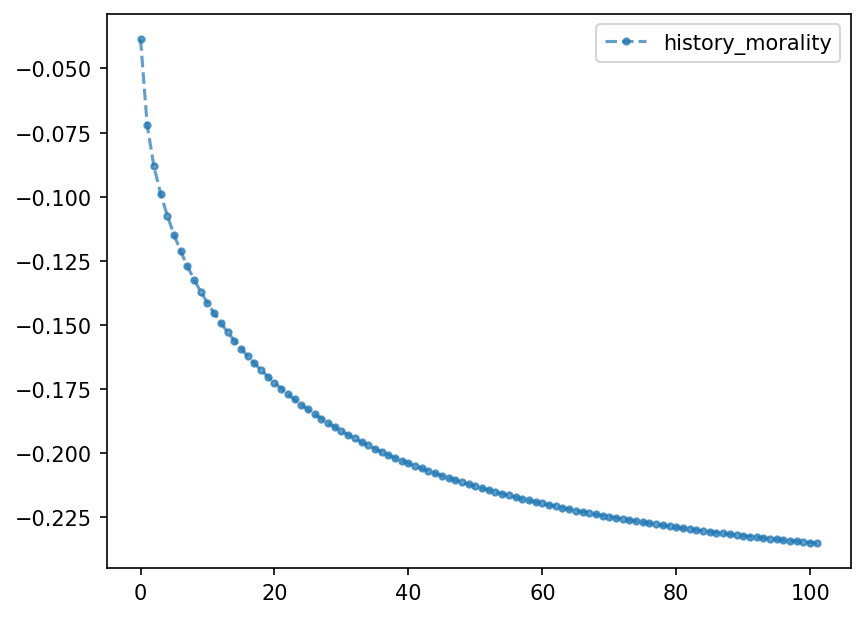

In [ ]:
plt.rcParams['figure.dpi'] = 150
mem = MoralEntrepreneurModelPlot(n_agents = 100, n_agents_mode = 4, max_periods = 100,
                            network_type = 'cycle', beliefs_mean = 0, beliefs_std = 1, strategy_type_me = 'common',
                            propaganda_me = 0, target_rate_me = 0.2, strategy_type_fd = 'common',
                            propaganda_fd = 0, target_rate_fd = 0.2)
mem.run()

_ = [plt.plot(mem.result[key], label=key, linestyle='--', marker='.', alpha=0.7) for key in [
    'history_morality'
]]
plt.legend()

# Grid Search Эксперимент

In [ ]:
import itertools
import pandas as pd
from tqdm import tqdm
import time

def run_simulation(n_agents_var, n_agents_mode_var, network_type_var, propaganda_me_var, propaganda_fd_var, strategy_type_me_var,
                   strategy_type_fd_var, target_rate_me_var, target_rate_fd_var, max_periods_var, beliefs_mean_var, beliefs_std_var, conformity_min_var, conformity_max_var, num_runs):
    run_list = []
    first_list = []
    last_list = []
    tenth_list = []
    thirtieth_list = []
    fiftieth_list = []
    seventieth_list = []
    ninetieth_list = []

    for run in range(num_runs):
        mem = MoralEntrepreneurModel(n_agents=n_agents_var, n_agents_mode=n_agents_mode_var, max_periods=max_periods_var,
                                     network_type=network_type_var, beliefs_mean=beliefs_mean_var, beliefs_std=beliefs_std_var,
                                     conformity_min=conformity_min_var, conformity_max=conformity_max_var,
                                     propaganda_me=propaganda_me_var, target_rate_me=target_rate_me_var, strategy_type_me=strategy_type_me_var,
                                     propaganda_fd=propaganda_fd_var, target_rate_fd=target_rate_fd_var, strategy_type_fd=strategy_type_fd_var)
        mem.run()
        first = mem.result['history_morality'][0]
        tenth = mem.result['history_morality'][9]
        thirtieth = mem.result['history_morality'][29]
        fiftieth = mem.result['history_morality'][49]
        seventieth = mem.result['history_morality'][69]
        ninetieth = mem.result['history_morality'][89]
        last = mem.result['history_morality'][-1]
        run_list.append(run + 1)
        first_list.append(first)
        tenth_list.append(tenth)
        thirtieth_list.append(thirtieth)
        fiftieth_list.append(fiftieth)
        seventieth_list.append(seventieth)
        ninetieth_list.append(ninetieth)
        last_list.append(last)

    df = pd.DataFrame({'run': run_list, 'first_list': first_list, 'last_list': last_list})

    win_me = (df[df['last_list'] >= 0].shape[0])/num_runs
    win_fd = (df[df['last_list'] < 0].shape[0])/num_runs

    df_final = pd.DataFrame({'n_agents' : n_agents_var, 'n_agents_mode' : n_agents_mode_var, 'network_type' : network_type_var,
                             'propaganda_me' : propaganda_me_var, 'propaganda_fd' : propaganda_fd_var, 'strategy_type_me' : strategy_type_me_var,
                             'strategy_type_fd' : strategy_type_fd_var, 'target_rate_me' : target_rate_me_var,
                              'target_rate_fd' : target_rate_fd_var, 'max_periods' : max_periods_var, 'beliefs_mean' : beliefs_mean_var, 'beliefs_std' : beliefs_std_var,
                              'conformity_min' : conformity_min_var,'conformity_max' : conformity_max_var,
                              'win_me' : win_me, 'win_fd' : win_fd, 'num_runs': num_runs, '1' : np.mean(first_list), '10' : np.mean(tenth_list),
                              '30' : np.mean(thirtieth_list), '50' : np.mean(fiftieth_list),
                              '70': np.mean(seventieth_list), '90': np.mean(ninetieth_list), 'last' : np.mean(last_list)}, index=[0])

    return df_final

n_agents_range = [100]
n_agents_mode_range = [5]
network_type_range = ['watts']
propaganda_me_range = [0.5, 1]
propaganda_fd_range = [0.5, 1]
strategy_type_me_range = ['common'] #, 'random_target', 'influencer_target', 'close_target', 'distance_target']
strategy_type_fd_range = ['common'] #, 'random_target', 'influencer_target', 'close_target', 'distance_target']
target_rate_me_range = [0.2]
target_rate_fd_range = [0.2]
max_periods_range = [100]
beliefs_mean_range = [0]
beliefs_std_range = [1]
conformity_min_range = [0]
conformity_max_range = [1]
num_runs = 100

param_combinations = list(itertools.product(n_agents_range, n_agents_mode_range, network_type_range, propaganda_me_range,
                                            propaganda_fd_range, strategy_type_me_range, strategy_type_fd_range,
                                            target_rate_me_range, target_rate_fd_range, max_periods_range,
                                            beliefs_mean_range, beliefs_std_range,
                                            conformity_min_range, conformity_max_range))

total_iterations = len(param_combinations)
print(f'Всего: {total_iterations}')

start_time = time.time()
results = []

for params in tqdm(param_combinations, desc="Симуляции"):
    df_final = run_simulation(*params, num_runs)
    results.append(df_final)

# Combine all results into one DataFrame
combined_results = pd.concat(results, ignore_index=True)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Всего времени потрачено: {elapsed_time:.2f} секунд")

combined_results

Всего: 4


Симуляции: 100%|██████████| 4/4 [00:21<00:00,  5.37s/it]

Всего времени потрачено: 21.53 секунд


,n_agents,n_agents_mode,network_type,propaganda_me,propaganda_fd,strategy_type_me,strategy_type_fd,target_rate_me,target_rate_fd,max_periods,...,win_me,win_fd,num_runs,1,10,30,50,70,90,last
0,100,5,watts,0.5,0.5,common,common,0.2,0.2,100,...,0.43,0.57,100,0.003683,-0.005896,-0.008561,-0.008222,-0.007440,-0.006716,-0.006353
1,100,5,watts,0.5,1.0,common,common,0.2,0.2,100,...,0.00,1.00,100,0.003612,-0.234844,-0.788185,-0.993544,-0.999837,-1.000000,-1.000000
2,100,5,watts,1.0,0.5,common,common,0.2,0.2,100,...,1.00,0.00,100,0.005197,0.252394,0.802102,0.991503,0.999593,1.000000,1.000000
3,100,5,watts,1.0,1.0,common,common,0.2,0.2,100,...,0.49,0.51,100,-0.003653,-0.013391,-0.015861,-0.017129,-0.018658,-0.020241,-0.021177


In [ ]:
combined_results.to_latex()

'\\begin{tabular}{lrrlrrllrrrrrrrr}\n\\toprule\n & n_agents & n_agents_mode & network_type & propaganda_me & propaganda_fd & strategy_type_me & strategy_type_fd & target_rate_me & target_rate_fd & max_periods & beliefs_mean & beliefs_std & win_me & win_fd & num_runs \\\\\n\\midrule\n0 & 100 & 5 & watts & 0.500000 & 0.500000 & common & common & 0.200000 & 0.200000 & 100 & 0 & 1 & 0.440000 & 0.560000 & 100 \\\\\n1 & 100 & 5 & watts & 0.500000 & 0.500000 & common & common & 0.200000 & 0.300000 & 100 & 0 & 1 & 0.580000 & 0.420000 & 100 \\\\\n2 & 100 & 5 & watts & 0.500000 & 0.500000 & common & common & 0.300000 & 0.200000 & 100 & 0 & 1 & 0.380000 & 0.620000 & 100 \\\\\n3 & 100 & 5 & watts & 0.500000 & 0.500000 & common & common & 0.300000 & 0.300000 & 100 & 0 & 1 & 0.430000 & 0.570000 & 100 \\\\\n4 & 100 & 5 & watts & 0.500000 & 1.000000 & common & common & 0.200000 & 0.200000 & 100 & 0 & 1 & 0.140000 & 0.860000 & 100 \\\\\n5 & 100 & 5 & watts & 0.500000 & 1.000000 & common & common & 0.20